In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## EDA

In [2]:
from pathlib import Path
file = Path.cwd().parent / 'energy-usage-2010-1.csv'
df =  pd.read_csv(file)
df

,index,COMMUNITY AREA NAME,CENSUS BLOCK,BUILDING TYPE,BUILDING_SUBTYPE,KWH JANUARY 2010,KWH FEBRUARY 2010,KWH MARCH 2010,KWH APRIL 2010,KWH MAY 2010,...,TOTAL POPULATION,TOTAL UNITS,AVERAGE STORIES,AVERAGE BUILDING AGE,AVERAGE HOUSESIZE,OCCUPIED UNITS,OCCUPIED UNITS PERCENTAGE,RENTER-OCCUPIED HOUSING UNITS,RENTER-OCCUPIED HOUSING PERCENTAGE,OCCUPIED HOUSING UNITS
0,0,Archer Heights,1.703157e+14,Residential,Multi < 7,NaN,NaN,NaN,NaN,NaN,...,89.0,24.0,2.00,71.33,3.87,23.0,0.9582,9.0,0.3910,23.0
1,1,Ashburn,1.703170e+14,Residential,Multi 7+,7334.0,7741.0,4214.0,4284.0,2518.0,...,112.0,67.0,2.00,41.00,1.81,62.0,0.9254,50.0,0.8059,62.0
2,2,Auburn Gresham,1.703171e+14,Commercial,Multi < 7,NaN,NaN,NaN,NaN,NaN,...,102.0,48.0,3.00,86.00,3.00,34.0,0.7082,23.0,0.6759,34.0
3,3,Austin,1.703125e+14,Commercial,Multi < 7,NaN,NaN,NaN,NaN,NaN,...,121.0,56.0,2.00,84.00,2.95,41.0,0.7321,32.0,0.7800,41.0
4,4,Austin,1.703125e+14,Commercial,Multi < 7,NaN,NaN,NaN,NaN,NaN,...,62.0,23.0,2.00,85.00,3.26,19.0,0.8261,11.0,0.5790,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67046,67046,Woodlawn,1.703184e+14,Residential,Single Family,2705.0,1318.0,1582.0,1465.0,1494.0,...,116.0,55.0,1.00,0.00,3.14,37.0,0.6727,26.0,0.7030,37.0
67047,67047,Woodlawn,1.703184e+14,Commercial,Multi < 7,1005.0,1760.0,1521.0,1832.0,2272.0,...,31.0,24.0,3.00,104.50,2.07,15.0,0.6250,13.0,0.8670,15.0
67048,67048,Woodlawn,1.703184e+14,Residential,Multi < 7,3567.0,3031.0,2582.0,2295.0,7902.0,...,31.0,24.0,2.33,100.67,2.07,15.0,0.6250,13.0,0.8670,15.0
67049,67049,Woodlawn,1.703184e+14,Residential,Single Family,1208.0,1055.0,1008.0,1109.0,1591.0,...,0.0,0.0,1.00,0.00,0.00,0.0,NaN,0.0,NaN,0.0


In [3]:
print(f"Number of Rows: ", len(df))
print(f"Number of Columns: ", df.shape[1])

Number of Rows:  67051
Number of Columns:  74


### Understand Columns

In [4]:
df.columns

Index(['index', 'COMMUNITY AREA NAME', 'CENSUS BLOCK', 'BUILDING TYPE',
       'BUILDING_SUBTYPE', 'KWH JANUARY 2010', 'KWH FEBRUARY 2010',
       'KWH MARCH 2010', 'KWH APRIL 2010', 'KWH MAY 2010', 'KWH JUNE 2010',
       'KWH JULY 2010', 'KWH AUGUST 2010', 'KWH SEPTEMBER 2010',
       'KWH OCTOBER 2010', 'KWH NOVEMBER 2010', 'KWH DECEMBER 2010',
       'TOTAL KWH', 'ELECTRICITY ACCOUNTS', 'ZERO KWH ACCOUNTS',
       'THERM JANUARY 2010', 'THERM FEBRUARY 2010', 'THERM MARCH 2010',
       'TERM APRIL 2010', 'THERM MAY 2010', 'THERM JUNE 2010',
       'THERM JULY 2010', 'THERM AUGUST 2010', 'THERM SEPTEMBER 2010',
       'THERM OCTOBER 2010', 'THERM NOVEMBER 2010', 'THERM DECEMBER 2010',
       'TOTAL THERMS', 'GAS ACCOUNTS', 'KWH TOTAL SQFT', 'THERMS TOTAL SQFT',
       'KWH MEAN 2010', 'KWH STANDARD DEVIATION 2010', 'KWH MINIMUM 2010',
       'KWH 1ST QUARTILE 2010', 'KWH 2ND QUARTILE 2010',
       'KWH 3RD QUARTILE 2010', 'KWH MAXIMUM 2010', 'KWH SQFT MEAN 2010',
       'KWH SQFT STA

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67051 entries, 0 to 67050
Data columns (total 74 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   index                                67051 non-null  int64  
 1   COMMUNITY AREA NAME                  67051 non-null  object 
 2   CENSUS BLOCK                         66974 non-null  float64
 3   BUILDING TYPE                        66974 non-null  object 
 4   BUILDING_SUBTYPE                     66974 non-null  object 
 5   KWH JANUARY 2010                     66180 non-null  float64
 6   KWH FEBRUARY 2010                    66180 non-null  float64
 7   KWH MARCH 2010                       66180 non-null  float64
 8   KWH APRIL 2010                       66180 non-null  float64
 9   KWH MAY 2010                         66180 non-null  float64
 10  KWH JUNE 2010                        66180 non-null  float64
 11  KWH JULY 2010               

**Each row represents the energy and gas usage of various buildings in communities of Chicago. Rows represent monthly and yearly totals as well as respective means and standard deviations. Row also represent energy per square footage to represent efficiency.**

*KWH, THERMS, Building Type, SQFT Total - KWH and THERMS* - possible important variables from first glance

*KWH + THERMS Total SQFT look like possible target variables*

### Cleaning

**Index is an unnecessary column**

In [6]:
df.drop(columns=['index'], inplace=True)
df

,COMMUNITY AREA NAME,CENSUS BLOCK,BUILDING TYPE,BUILDING_SUBTYPE,KWH JANUARY 2010,KWH FEBRUARY 2010,KWH MARCH 2010,KWH APRIL 2010,KWH MAY 2010,KWH JUNE 2010,...,TOTAL POPULATION,TOTAL UNITS,AVERAGE STORIES,AVERAGE BUILDING AGE,AVERAGE HOUSESIZE,OCCUPIED UNITS,OCCUPIED UNITS PERCENTAGE,RENTER-OCCUPIED HOUSING UNITS,RENTER-OCCUPIED HOUSING PERCENTAGE,OCCUPIED HOUSING UNITS
0,Archer Heights,1.703157e+14,Residential,Multi < 7,NaN,NaN,NaN,NaN,NaN,NaN,...,89.0,24.0,2.00,71.33,3.87,23.0,0.9582,9.0,0.3910,23.0
1,Ashburn,1.703170e+14,Residential,Multi 7+,7334.0,7741.0,4214.0,4284.0,2518.0,4273.0,...,112.0,67.0,2.00,41.00,1.81,62.0,0.9254,50.0,0.8059,62.0
2,Auburn Gresham,1.703171e+14,Commercial,Multi < 7,NaN,NaN,NaN,NaN,NaN,NaN,...,102.0,48.0,3.00,86.00,3.00,34.0,0.7082,23.0,0.6759,34.0
3,Austin,1.703125e+14,Commercial,Multi < 7,NaN,NaN,NaN,NaN,NaN,NaN,...,121.0,56.0,2.00,84.00,2.95,41.0,0.7321,32.0,0.7800,41.0
4,Austin,1.703125e+14,Commercial,Multi < 7,NaN,NaN,NaN,NaN,NaN,NaN,...,62.0,23.0,2.00,85.00,3.26,19.0,0.8261,11.0,0.5790,19.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67046,Woodlawn,1.703184e+14,Residential,Single Family,2705.0,1318.0,1582.0,1465.0,1494.0,2990.0,...,116.0,55.0,1.00,0.00,3.14,37.0,0.6727,26.0,0.7030,37.0
67047,Woodlawn,1.703184e+14,Commercial,Multi < 7,1005.0,1760.0,1521.0,1832.0,2272.0,2361.0,...,31.0,24.0,3.00,104.50,2.07,15.0,0.6250,13.0,0.8670,15.0
67048,Woodlawn,1.703184e+14,Residential,Multi < 7,3567.0,3031.0,2582.0,2295.0,7902.0,4987.0,...,31.0,24.0,2.33,100.67,2.07,15.0,0.6250,13.0,0.8670,15.0
67049,Woodlawn,1.703184e+14,Residential,Single Family,1208.0,1055.0,1008.0,1109.0,1591.0,1367.0,...,0.0,0.0,1.00,0.00,0.00,0.0,NaN,0.0,NaN,0.0


In [7]:
df.isnull().sum().sort_values(ascending=False)

THERMS SQFT STANDARD DEVIATION 2010    15684
KWH SQFT STANDARD DEVIATION 2010       15385
THERM STANDARD DEVIATION 2010          10230
KWH STANDARD DEVIATION 2010             9956
THERM FEBRUARY 2010                     4232
                                       ...  
TOTAL POPULATION                          14
AVERAGE BUILDING AGE                       0
AVERAGE STORIES                            0
ZERO KWH ACCOUNTS                          0
COMMUNITY AREA NAME                        0
Length: 73, dtype: int64

In [8]:
(df.isna().sum() / len(df)).sort_values(ascending=False) * 100

THERMS SQFT STANDARD DEVIATION 2010    23.391150
KWH SQFT STANDARD DEVIATION 2010       22.945221
THERM STANDARD DEVIATION 2010          15.257043
KWH STANDARD DEVIATION 2010            14.848399
THERM FEBRUARY 2010                     6.311614
                                         ...    
TOTAL POPULATION                        0.020880
AVERAGE BUILDING AGE                    0.000000
AVERAGE STORIES                         0.000000
ZERO KWH ACCOUNTS                       0.000000
COMMUNITY AREA NAME                     0.000000
Length: 73, dtype: float64

In [9]:
df.select_dtypes(include=['object']).isna().sum()

COMMUNITY AREA NAME        0
BUILDING TYPE             77
BUILDING_SUBTYPE          77
ELECTRICITY ACCOUNTS     871
GAS ACCOUNTS            1296
dtype: int64

**The amount of rows dropped is a very small percentage of the data available.**

In [10]:
columns = ['CENSUS BLOCK', 'BUILDING TYPE', 'BUILDING_SUBTYPE', 'OCCUPIED UNITS', 'RENTER-OCCUPIED HOUSING UNITS', 'OCCUPIED HOUSING UNITS', 'ELECTRICITY ACCOUNTS', 'GAS ACCOUNTS']
df = df.dropna(subset=columns)
len(df)

64800

In [11]:
df.isna().sum()

COMMUNITY AREA NAME                      0
CENSUS BLOCK                             0
BUILDING TYPE                            0
BUILDING_SUBTYPE                         0
KWH JANUARY 2010                         0
                                      ... 
OCCUPIED UNITS                           0
OCCUPIED UNITS PERCENTAGE             2157
RENTER-OCCUPIED HOUSING UNITS            0
RENTER-OCCUPIED HOUSING PERCENTAGE    2307
OCCUPIED HOUSING UNITS                   0
Length: 73, dtype: int64

In [12]:
df['THERMS TOTAL SQFT'].isna().sum()

376

In [13]:
df['KWH TOTAL SQFT'].isna().sum()

279

In [14]:
(df.isna().sum() / len(df)).sort_values(ascending=False) * 100

THERMS SQFT STANDARD DEVIATION 2010    21.229938
KWH SQFT STANDARD DEVIATION 2010       20.783951
THERM STANDARD DEVIATION 2010          12.947531
KWH STANDARD DEVIATION 2010            12.722222
THERM FEBRUARY 2010                     4.395062
                                         ...    
CENSUS BLOCK                            0.000000
KWH MINIMUM 2010                        0.000000
KWH 1ST QUARTILE 2010                   0.000000
KWH 2ND QUARTILE 2010                   0.000000
OCCUPIED HOUSING UNITS                  0.000000
Length: 73, dtype: float64

**Standard Deviation Columns may be useless**

In [15]:
sd_columns = ['THERMS SQFT STANDARD DEVIATION 2010', 'KWH SQFT STANDARD DEVIATION 2010',
              'THERM STANDARD DEVIATION 2010', 'KWH STANDARD DEVIATION 2010']
df = df.drop(columns=sd_columns)
df.shape[1]

69

In [16]:
(df.isna().sum() / len(df)).sort_values(ascending=False) * 100

THERM FEBRUARY 2010                   4.395062
RENTER-OCCUPIED HOUSING PERCENTAGE    3.560185
OCCUPIED UNITS PERCENTAGE             3.328704
THERM SEPTEMBER 2010                  1.341049
THERM JANUARY 2010                    1.330247
                                        ...   
KWH MEAN 2010                         0.000000
KWH MINIMUM 2010                      0.000000
KWH 1ST QUARTILE 2010                 0.000000
KWH 2ND QUARTILE 2010                 0.000000
OCCUPIED HOUSING UNITS                0.000000
Length: 69, dtype: float64

**Inspect for 0s as missing**

In [17]:
df

,COMMUNITY AREA NAME,CENSUS BLOCK,BUILDING TYPE,BUILDING_SUBTYPE,KWH JANUARY 2010,KWH FEBRUARY 2010,KWH MARCH 2010,KWH APRIL 2010,KWH MAY 2010,KWH JUNE 2010,...,TOTAL POPULATION,TOTAL UNITS,AVERAGE STORIES,AVERAGE BUILDING AGE,AVERAGE HOUSESIZE,OCCUPIED UNITS,OCCUPIED UNITS PERCENTAGE,RENTER-OCCUPIED HOUSING UNITS,RENTER-OCCUPIED HOUSING PERCENTAGE,OCCUPIED HOUSING UNITS
96,Lakeview,1.703106e+14,Residential,Multi 7+,1526.0,1665.0,1824.0,1579.0,2916.0,4211.0,...,74.0,45.0,3.00,12.00,2.00,37.0,0.8222,3.0,0.0810,37.0
102,Lincoln Park,1.703107e+14,Residential,Multi 7+,242.0,136.0,134.0,134.0,144.0,122.0,...,61.0,22.0,4.00,12.00,2.77,22.0,1.0000,11.0,0.5000,22.0
103,Lincoln Park,1.703107e+14,Commercial,Multi 7+,0.0,0.0,0.0,0.0,0.0,9.0,...,111.0,88.0,4.00,0.00,1.79,62.0,0.7045,39.0,0.6290,62.0
119,Logan Square,1.703183e+14,Commercial,Commercial,6171.0,3593.0,3812.0,4376.0,4431.0,5945.0,...,101.0,39.0,1.00,0.00,2.59,39.0,1.0000,11.0,0.2820,39.0
130,Near North Side,1.703108e+14,Residential,Multi < 7,1959.0,2039.0,1647.0,1504.0,1790.0,3340.0,...,36.0,18.0,3.00,116.00,2.00,18.0,1.0000,12.0,0.6670,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67046,Woodlawn,1.703184e+14,Residential,Single Family,2705.0,1318.0,1582.0,1465.0,1494.0,2990.0,...,116.0,55.0,1.00,0.00,3.14,37.0,0.6727,26.0,0.7030,37.0
67047,Woodlawn,1.703184e+14,Commercial,Multi < 7,1005.0,1760.0,1521.0,1832.0,2272.0,2361.0,...,31.0,24.0,3.00,104.50,2.07,15.0,0.6250,13.0,0.8670,15.0
67048,Woodlawn,1.703184e+14,Residential,Multi < 7,3567.0,3031.0,2582.0,2295.0,7902.0,4987.0,...,31.0,24.0,2.33,100.67,2.07,15.0,0.6250,13.0,0.8670,15.0
67049,Woodlawn,1.703184e+14,Residential,Single Family,1208.0,1055.0,1008.0,1109.0,1591.0,1367.0,...,0.0,0.0,1.00,0.00,0.00,0.0,NaN,0.0,NaN,0.0


In [18]:
df_clean = df.dropna()
len(df)

64800

In [19]:
df_clean

,COMMUNITY AREA NAME,CENSUS BLOCK,BUILDING TYPE,BUILDING_SUBTYPE,KWH JANUARY 2010,KWH FEBRUARY 2010,KWH MARCH 2010,KWH APRIL 2010,KWH MAY 2010,KWH JUNE 2010,...,TOTAL POPULATION,TOTAL UNITS,AVERAGE STORIES,AVERAGE BUILDING AGE,AVERAGE HOUSESIZE,OCCUPIED UNITS,OCCUPIED UNITS PERCENTAGE,RENTER-OCCUPIED HOUSING UNITS,RENTER-OCCUPIED HOUSING PERCENTAGE,OCCUPIED HOUSING UNITS
102,Lincoln Park,1.703107e+14,Residential,Multi 7+,242.0,136.0,134.0,134.0,144.0,122.0,...,61.0,22.0,4.00,12.00,2.77,22.0,1.0000,11.0,0.5000,22.0
103,Lincoln Park,1.703107e+14,Commercial,Multi 7+,0.0,0.0,0.0,0.0,0.0,9.0,...,111.0,88.0,4.00,0.00,1.79,62.0,0.7045,39.0,0.6290,62.0
130,Near North Side,1.703108e+14,Residential,Multi < 7,1959.0,2039.0,1647.0,1504.0,1790.0,3340.0,...,36.0,18.0,3.00,116.00,2.00,18.0,1.0000,12.0,0.6670,18.0
187,South Chicago,1.703183e+14,Commercial,Multi 7+,3295.0,2934.0,2061.0,1917.0,3491.0,5254.0,...,100.0,42.0,1.00,0.00,2.94,34.0,0.8095,21.0,0.6180,34.0
198,South Shore,1.703143e+14,Commercial,Multi < 7,383.0,690.0,1227.0,1921.0,1190.0,3216.0,...,187.0,98.0,1.00,0.00,2.56,73.0,0.7448,67.0,0.9179,73.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67045,Woodlawn,1.703184e+14,Residential,Multi < 7,9572.0,9104.0,8525.0,7756.0,11256.0,11669.0,...,116.0,55.0,2.00,51.90,3.14,37.0,0.6727,26.0,0.7030,37.0
67046,Woodlawn,1.703184e+14,Residential,Single Family,2705.0,1318.0,1582.0,1465.0,1494.0,2990.0,...,116.0,55.0,1.00,0.00,3.14,37.0,0.6727,26.0,0.7030,37.0
67047,Woodlawn,1.703184e+14,Commercial,Multi < 7,1005.0,1760.0,1521.0,1832.0,2272.0,2361.0,...,31.0,24.0,3.00,104.50,2.07,15.0,0.6250,13.0,0.8670,15.0
67048,Woodlawn,1.703184e+14,Residential,Multi < 7,3567.0,3031.0,2582.0,2295.0,7902.0,4987.0,...,31.0,24.0,2.33,100.67,2.07,15.0,0.6250,13.0,0.8670,15.0


- **15,000 rows out of 67,000 rows is a considerably effective percentage that could affect model performance/results**

- **Should I either drop or fill in the missing values?**

- **Because the missing data consistues about 23% of the data, dropping the rows/data points would be too risky. So imputation would be a better strategy in terms of prediction.**

- **I should probably impute with the median or mean value**
- **But honestly I can just drop those columns because I can recalculate them or they might not be necessary.**

In [20]:
df_clean['BUILDING TYPE'].value_counts()

BUILDING TYPE
Residential    45122
Commercial     12440
Industrial        15
Name: count, dtype: int64

### Numerical Feature Exploration

In [21]:
df_clean.describe()

,CENSUS BLOCK,KWH JANUARY 2010,KWH FEBRUARY 2010,KWH MARCH 2010,KWH APRIL 2010,KWH MAY 2010,KWH JUNE 2010,KWH JULY 2010,KWH AUGUST 2010,KWH SEPTEMBER 2010,...,TOTAL POPULATION,TOTAL UNITS,AVERAGE STORIES,AVERAGE BUILDING AGE,AVERAGE HOUSESIZE,OCCUPIED UNITS,OCCUPIED UNITS PERCENTAGE,RENTER-OCCUPIED HOUSING UNITS,RENTER-OCCUPIED HOUSING PERCENTAGE,OCCUPIED HOUSING UNITS
count,5.757700e+04,5.757700e+04,5.757700e+04,5.757700e+04,5.757700e+04,5.757700e+04,5.757700e+04,5.757700e+04,5.757700e+04,5.757700e+04,...,57577.000000,57577.000000,57577.000000,57577.000000,57577.000000,57577.000000,57577.000000,57577.000000,57577.000000,57577.000000
mean,1.703140e+14,8.769488e+03,8.784872e+03,8.240266e+03,8.080009e+03,1.011629e+04,1.319022e+04,1.474883e+04,1.289418e+04,9.816742e+03,...,87.239210,39.495701,1.833951,72.812961,2.842254,34.826754,0.886334,20.281032,0.500260,34.826754
std,2.759482e+09,1.028279e+05,1.001573e+05,9.550698e+04,9.040620e+04,1.095019e+05,1.059792e+05,1.249992e+05,1.102755e+05,1.021297e+05,...,88.481477,57.159330,1.535302,32.321482,0.849232,50.465359,0.119031,37.643501,0.288263,50.465359
min,1.703101e+14,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.011200,0.000000,0.000000,1.000000
25%,1.703115e+14,1.486000e+03,1.752000e+03,1.720000e+03,1.712000e+03,2.124000e+03,2.948000e+03,3.487000e+03,3.064000e+03,2.198000e+03,...,41.000000,16.000000,1.170000,55.140000,2.220000,14.000000,0.840000,4.000000,0.266000,14.000000
50%,1.703131e+14,3.603000e+03,3.964000e+03,3.835000e+03,3.803000e+03,4.743000e+03,6.629000e+03,7.734000e+03,6.668000e+03,4.751000e+03,...,66.000000,26.000000,1.750000,80.250000,2.750000,23.000000,0.916700,11.000000,0.526000,23.000000
75%,1.703166e+14,7.122000e+03,7.399000e+03,7.053000e+03,7.015000e+03,8.971000e+03,1.295200e+04,1.479200e+04,1.235300e+04,8.645000e+03,...,106.000000,43.000000,2.000000,96.000000,3.350000,37.000000,0.969700,23.000000,0.722000,37.000000
max,1.703184e+14,1.742132e+07,1.788066e+07,1.850369e+07,1.729024e+07,2.134405e+07,1.877248e+07,2.147804e+07,1.858696e+07,1.926164e+07,...,1496.000000,1365.000000,83.000000,153.500000,12.000000,1034.000000,1.000000,993.000000,1.000000,1034.000000


### Averages

In [22]:
print(f"mean annual energy production:", df_clean['TOTAL KWH'].mean())
print(f"median annual energy production:", df_clean['TOTAL KWH'].median())

mean annual energy production: 129229.99824582733
median annual energy production: 65185.0


In [24]:
print(f"average building age: ", df_clean['AVERAGE BUILDING AGE'].mean())

average building age:  72.81296107820832


<Axes: >

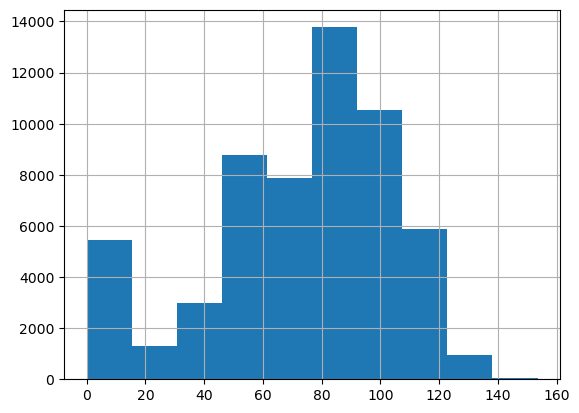

In [25]:
df_clean['AVERAGE BUILDING AGE'].hist()

In [26]:
df_clean['TOTAL POPULATION'].mean()

87.23921010125571

array([[<Axes: title={'center': 'CENSUS BLOCK'}>,
        <Axes: title={'center': 'KWH JANUARY 2010'}>,
        <Axes: title={'center': 'KWH FEBRUARY 2010'}>,
        <Axes: title={'center': 'KWH MARCH 2010'}>,
        <Axes: title={'center': 'KWH APRIL 2010'}>,
        <Axes: title={'center': 'KWH MAY 2010'}>,
        <Axes: title={'center': 'KWH JUNE 2010'}>,
        <Axes: title={'center': 'KWH JULY 2010'}>],
       [<Axes: title={'center': 'KWH AUGUST 2010'}>,
        <Axes: title={'center': 'KWH SEPTEMBER 2010'}>,
        <Axes: title={'center': 'KWH OCTOBER 2010'}>,
        <Axes: title={'center': 'KWH NOVEMBER 2010'}>,
        <Axes: title={'center': 'KWH DECEMBER 2010'}>,
        <Axes: title={'center': 'TOTAL KWH'}>,
        <Axes: title={'center': 'ZERO KWH ACCOUNTS'}>,
        <Axes: title={'center': 'THERM JANUARY 2010'}>],
       [<Axes: title={'center': 'THERM FEBRUARY 2010'}>,
        <Axes: title={'center': 'THERM MARCH 2010'}>,
        <Axes: title={'center': 'TERM APR

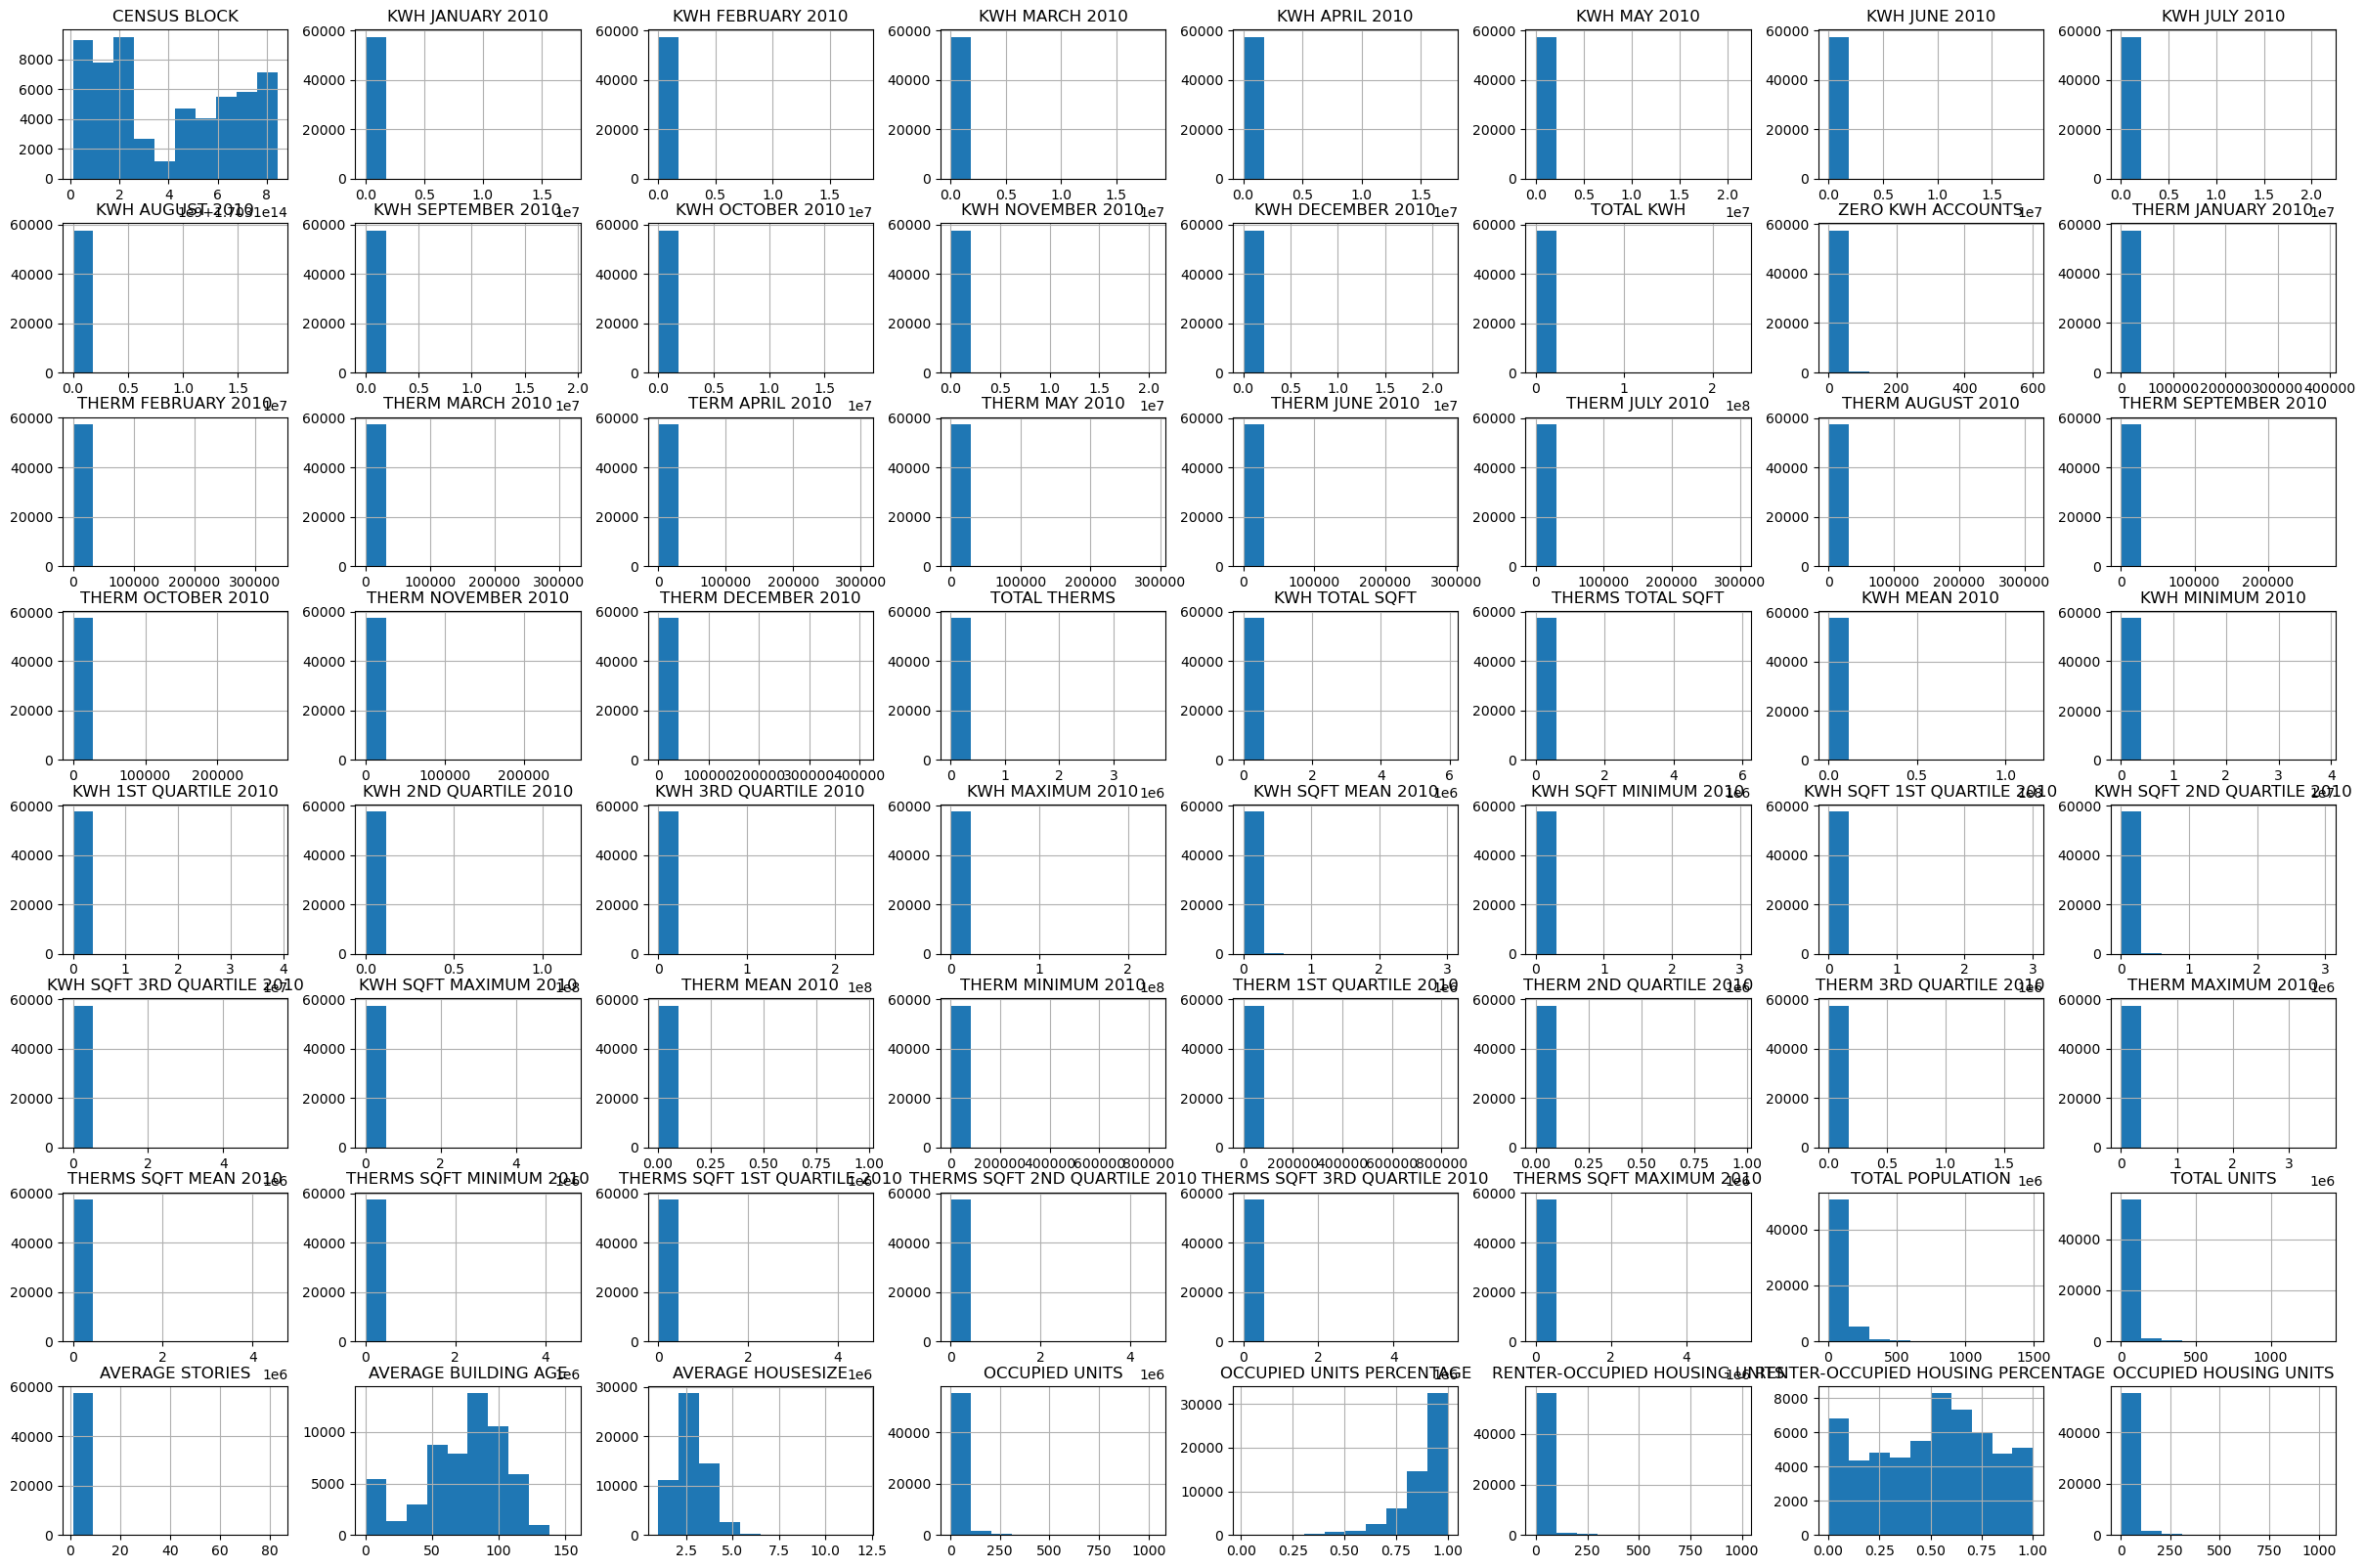

In [33]:
df_clean.hist(figsize=(30,20))

#### Initial Visualizations

#### Categorical Features

In [34]:
df_clean['BUILDING TYPE'].value_counts()

BUILDING TYPE
Residential    45122
Commercial     12440
Industrial        15
Name: count, dtype: int64

<Axes: xlabel='BUILDING TYPE'>

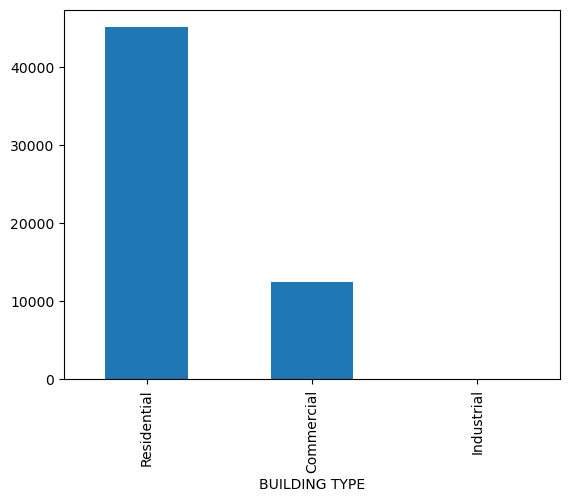

In [35]:
df_clean['BUILDING TYPE'].value_counts().plot.bar()

### Relationships

In [36]:
df_clean.corr(numeric_only=True)

,CENSUS BLOCK,KWH JANUARY 2010,KWH FEBRUARY 2010,KWH MARCH 2010,KWH APRIL 2010,KWH MAY 2010,KWH JUNE 2010,KWH JULY 2010,KWH AUGUST 2010,KWH SEPTEMBER 2010,...,TOTAL POPULATION,TOTAL UNITS,AVERAGE STORIES,AVERAGE BUILDING AGE,AVERAGE HOUSESIZE,OCCUPIED UNITS,OCCUPIED UNITS PERCENTAGE,RENTER-OCCUPIED HOUSING UNITS,RENTER-OCCUPIED HOUSING PERCENTAGE,OCCUPIED HOUSING UNITS
CENSUS BLOCK,1.000000,-0.023123,-0.022403,-0.023912,-0.024742,-0.028917,-0.034849,-0.026686,-0.023846,-0.021717,...,-0.162120,-0.173103,-0.132695,-0.002616,0.210572,-0.185904,-0.146443,-0.166183,-0.065132,-0.185904
KWH JANUARY 2010,-0.023123,1.000000,0.995486,0.986543,0.974203,0.974484,0.972653,0.962872,0.965612,0.975253,...,0.203959,0.250071,0.465545,-0.068246,-0.063580,0.228789,0.000854,0.152762,-0.002743,0.228789
KWH FEBRUARY 2010,-0.022403,0.995486,1.000000,0.991288,0.983021,0.983862,0.981400,0.973090,0.976721,0.984743,...,0.204727,0.247523,0.452932,-0.068943,-0.064123,0.227509,0.002378,0.152187,-0.001817,0.227509
KWH MARCH 2010,-0.023912,0.986543,0.991288,1.000000,0.993250,0.991110,0.984394,0.958956,0.966342,0.986764,...,0.214127,0.257333,0.465376,-0.074340,-0.067851,0.237073,0.003332,0.161950,0.000268,0.237073
KWH APRIL 2010,-0.024742,0.974203,0.983021,0.993250,1.000000,0.994877,0.985913,0.961376,0.968422,0.987249,...,0.207409,0.247760,0.434191,-0.076264,-0.068197,0.228807,0.005633,0.158146,-0.000424,0.228807
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OCCUPIED UNITS,-0.185904,0.228789,0.227509,0.237073,0.228807,0.238633,0.246743,0.226271,0.232356,0.237434,...,0.922196,0.991979,0.458793,-0.091423,-0.290869,1.000000,0.041184,0.911185,0.219118,1.000000
OCCUPIED UNITS PERCENTAGE,-0.146443,0.000854,0.002378,0.003332,0.005633,0.009811,0.018895,0.014877,0.009170,0.003376,...,0.038604,-0.030581,-0.070753,-0.164367,-0.071056,0.041184,1.000000,-0.012053,-0.292330,0.041184
RENTER-OCCUPIED HOUSING UNITS,-0.166183,0.152762,0.152187,0.161950,0.158146,0.165206,0.167288,0.149568,0.158310,0.164920,...,0.834193,0.908141,0.407432,-0.043869,-0.275437,0.911185,-0.012053,1.000000,0.398053,0.911185
RENTER-OCCUPIED HOUSING PERCENTAGE,-0.065132,-0.002743,-0.001817,0.000268,-0.000424,-0.006891,-0.017390,-0.015587,-0.005018,0.002652,...,0.255003,0.236079,0.179229,0.167359,-0.122681,0.219118,-0.292330,0.398053,1.000000,0.219118


In [ ]:
df_clean.corr()

#### Feature Engineering